<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h2>Ensemble</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score
from sklearn.pipeline import Pipeline

In [2]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display
from scripts.decision_tree import determine_parameter

In [3]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [4]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [5]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [8]:
numerical_features = X_train.select_dtypes(exclude='object').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [9]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']), 
    ], remainder=MinMaxScaler()
)

In [10]:
X_train = transformer.fit_transform(X_train)

In [11]:
X_test = transformer.transform(X_test)

<div style="font-family: Calibri; font-size: 16px; background-color: #e9edc9; padding: 5px;">
    <h4>- Using SMOTE, ADASYN</h4>
</div>

In [12]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [13]:
# Initialize the SMOTE
rus = SMOTETomek(random_state=42)

# Fit and apply the undersampling
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

In [14]:
# The resampled data is now balanced
print("Shape of X before undersampling:", X_train.shape)
print("Shape of X after undersampling:", X_resampled.shape)
print("Value counts before undersampling:", pd.Series(y_train).value_counts())
print("Value counts after undersampling:", pd.Series(y_resampled).value_counts())

Shape of X before undersampling: (204277, 23)
Shape of X after undersampling: (358878, 23)
Value counts before undersampling: Default
0    180524
1     23753
Name: count, dtype: int64
Value counts after undersampling: Default
0    179439
1    179439
Name: count, dtype: int64


In [15]:
X_train, y_train = X_resampled, y_resampled

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>4. Ensemble</h2>
</div>

In [16]:
import xgboost as xgb

In [17]:
model = xgb.XGBClassifier(objective='binary:logistic', 
                          eval_metric=make_scorer(fbeta_score, beta=2, pos_label=1),
                          enable_categorical=True,
                          # eval_metric=make_scorer(recall_score, pos_label=1),
                          random_state=42)

In [18]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True,
              eval_metric=make_scorer(fbeta_score, response_method='predict', beta=2, pos_label=1),
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [28]:
rs = recall_score(y_test, y_pred, pos_label=1)
ps = precision_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
ac = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)
print(f"{'Recall Score:':<20}{rs:.3}")
print(f"{'Precision Score:':<20}{ps:.3}")
print(f"{'F1 Score:':<20}{f1:.3}")
print(f"{'ROC AUC Score:':<20}{roc:.3}")
print(f"{'Accuracy Score:':<20}{ac:.3}")

Recall Score:       0.114
Precision Score:    0.497
F1 Score:           0.185
ROC AUC Score:      0.549
Accuracy Score:     0.884


In [20]:
y_pred = model.predict(X_test)

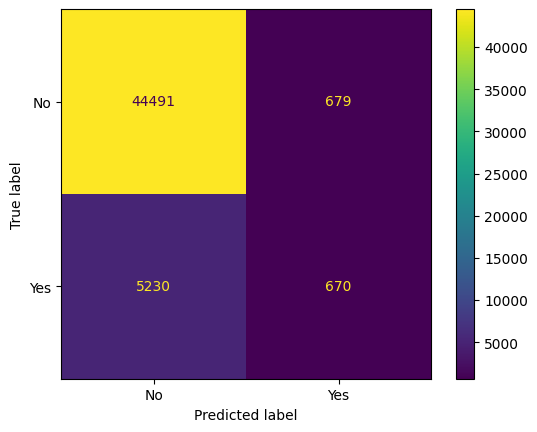

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format='d', display_labels=["No","Yes"]);

In [22]:
y_train_pred_prob, y_test_pred_prob = calc_predict_proba(model, X_train, y_train, X_test, y_test)

In [23]:
rs_list, ps_list, f1_list, ac_list = [],[],[],[]
for thresh in np.arange(0.3,0.8,0.1):
    rs, ps, f1, ac, y_test_pred = calc_scores(model, X_train, y_train, y_train_pred_prob, X_test, y_test, y_test_pred_prob, thresh)
    rs_list.append(rs) 
    ps_list.append(ps)
    f1_list.append(f1)
    ac_list.append(ac)

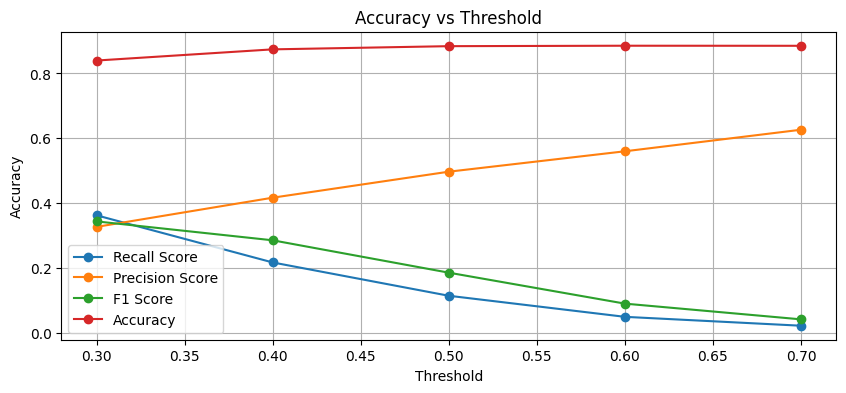

In [24]:
plt.figure(figsize=(10, 4))

plt.plot(np.arange(0.3,0.8,0.1), rs_list, label='Recall Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ps_list, label='Precision Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), f1_list, label='F1 Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ac_list, label='Accuracy', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.savefig("images/XGBClassifier.png")
plt.show()

In [25]:
pd.DataFrame({"recall": rs_list, "precision": ps_list, "f1-score": f1_list, "accuracy":ac_list}, index = np.arange(0.3,0.8,0.1))

,recall,precision,f1-score,accuracy
0.300,0.362,0.326,0.343,0.840
0.400,0.216,0.416,0.285,0.874
0.500,0.114,0.497,0.185,0.884
0.600,0.048,0.560,0.089,0.886
0.700,0.021,0.626,0.041,0.885
